<a href="https://colab.research.google.com/github/Prathama-1/Prosperity-4---Solo42/blob/main/Round5_manual_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

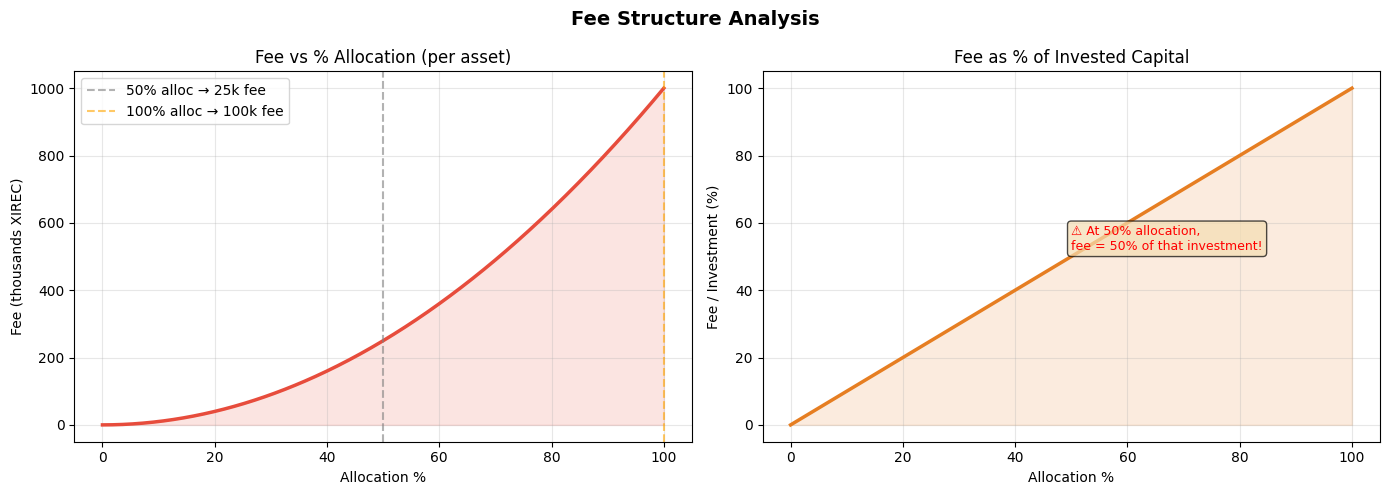

KEY INSIGHT: fee/investment = allocation% itself
→ If you put 10% in one asset, fee = 10% of that allocation = 1% of total budget
→ If you put 50% in one asset, fee = 50% of that allocation = 25% of total budget!

Fee table:
    5% alloc → fee =      2,500 XIREC  (5.0% of that position's capital)
   10% alloc → fee =     10,000 XIREC  (10.0% of that position's capital)
   15% alloc → fee =     22,500 XIREC  (15.0% of that position's capital)
   20% alloc → fee =     40,000 XIREC  (20.0% of that position's capital)
   25% alloc → fee =     62,500 XIREC  (25.0% of that position's capital)
   30% alloc → fee =     90,000 XIREC  (30.0% of that position's capital)
   40% alloc → fee =    160,000 XIREC  (40.0% of that position's capital)
   50% alloc → fee =    250,000 XIREC  (50.0% of that position's capital)
  100% alloc → fee =  1,000,000 XIREC  (100.0% of that position's capital)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import minimize, differential_evolution
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────
BUDGET = 1_000_000

def fee(pct: float, budget: float = BUDGET) -> float:
    """Fee for a single asset given % allocation (0-100)."""
    return (pct / 100) ** 2 * budget

def total_fee(pcts: list, budget: float = BUDGET) -> float:
    """Total fee across all assets."""
    return sum(fee(p, budget) for p in pcts)

# ─── Visualize fee structure ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fee Structure Analysis', fontsize=14, fontweight='bold')

v = np.linspace(0, 100, 500)
fees = (v / 100) ** 2 * BUDGET
marginal = 2 * v / 10000 * BUDGET  # d(fee)/dv

axes[0].plot(v, fees / 1000, color='#e74c3c', linewidth=2.5)
axes[0].set_title('Fee vs % Allocation (per asset)')
axes[0].set_xlabel('Allocation %')
axes[0].set_ylabel('Fee (thousands XIREC)')
axes[0].fill_between(v, fees / 1000, alpha=0.15, color='#e74c3c')
axes[0].axvline(50, color='gray', linestyle='--', alpha=0.6, label='50% alloc → 25k fee')
axes[0].axvline(100, color='orange', linestyle='--', alpha=0.6, label='100% alloc → 100k fee')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Fee as % of invested capital = (v/100)^2 * budget / (v/100 * budget) = v/100
fee_pct_of_invested = v / 100 * 100  # this equals v %
axes[1].plot(v, fee_pct_of_invested, color='#e67e22', linewidth=2.5)
axes[1].set_title('Fee as % of Invested Capital')
axes[1].set_xlabel('Allocation %')
axes[1].set_ylabel('Fee / Investment (%)')
axes[1].fill_between(v, fee_pct_of_invested, alpha=0.15, color='#e67e22')
axes[1].grid(alpha=0.3)
axes[1].text(50, 52, '⚠ At 50% allocation,\nfee = 50% of that investment!',
             fontsize=9, color='red', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('fee_structure.png', dpi=150, bbox_inches='tight')
plt.show()

print("KEY INSIGHT: fee/investment = allocation% itself")
print("→ If you put 10% in one asset, fee = 10% of that allocation = 1% of total budget")
print("→ If you put 50% in one asset, fee = 50% of that allocation = 25% of total budget!")
print("\nFee table:")
for pct in [5, 10, 15, 20, 25, 30, 40, 50, 100]:
    f = fee(pct)
    invested = pct / 100 * BUDGET
    print(f"  {pct:3d}% alloc → fee = {f:>10,.0f} XIREC  ({f/invested*100:.1f}% of that position's capital)")

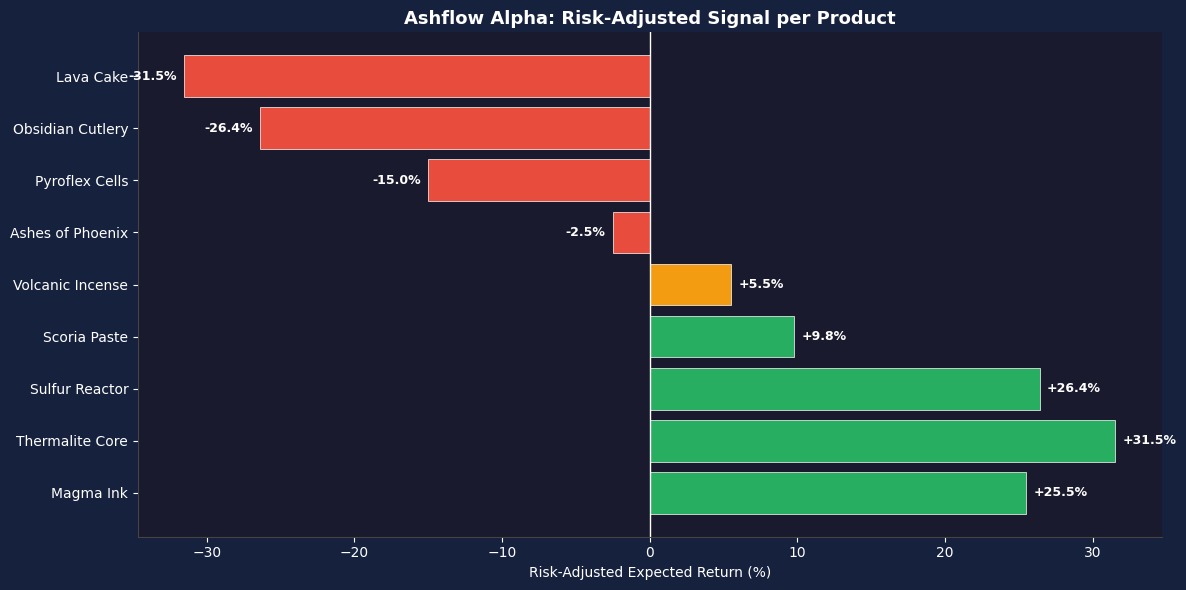

                    sentiment  exp_return  conf  risk_adj_return
Magma Ink          Strong Buy        0.30  0.85           0.2550
Thermalite Core    Strong Buy        0.35  0.90           0.3150
Sulfur Reactor     Strong Buy        0.30  0.88           0.2640
Scoria Paste              Buy        0.15  0.65           0.0975
Volcanic Incense     Weak Buy        0.10  0.55           0.0550
Ashes of Phoenix  Slight Sell       -0.05  0.50          -0.0250
Pyroflex Cells           Sell       -0.20  0.75          -0.1500
Obsidian Cutlery  Strong Sell       -0.30  0.88          -0.2640
Lava Cake         Strong Sell       -0.35  0.90          -0.3150


In [2]:
# ─────────────────────────────────────────────
# NEWS SENTIMENT & EXPECTED RETURN ESTIMATES
# ─────────────────────────────────────────────

# Products with their sentiment scores and estimated return ranges
# score: expected directional return (fraction of investment)
# confidence: how certain we are (affects position sizing)
# direction: +1 buy, -1 sell

products = {
    'Magma Ink':          {'sentiment': 'Strong Buy',   'exp_return': 0.30,  'conf': 0.85, 'direction': 1},
    'Thermalite Core':    {'sentiment': 'Strong Buy',   'exp_return': 0.35,  'conf': 0.90, 'direction': 1},
    'Sulfur Reactor':     {'sentiment': 'Strong Buy',   'exp_return': 0.30,  'conf': 0.88, 'direction': 1},
    'Scoria Paste':       {'sentiment': 'Buy',          'exp_return': 0.15,  'conf': 0.65, 'direction': 1},
    'Volcanic Incense':   {'sentiment': 'Weak Buy',     'exp_return': 0.10,  'conf': 0.55, 'direction': 1},
    'Ashes of Phoenix':   {'sentiment': 'Slight Sell',  'exp_return': -0.05, 'conf': 0.50, 'direction': -1},
    'Pyroflex Cells':     {'sentiment': 'Sell',         'exp_return': -0.20, 'conf': 0.75, 'direction': -1},
    'Obsidian Cutlery':   {'sentiment': 'Strong Sell',  'exp_return': -0.30, 'conf': 0.88, 'direction': -1},
    'Lava Cake':          {'sentiment': 'Strong Sell',  'exp_return': -0.35, 'conf': 0.90, 'direction': -1},
}

df = pd.DataFrame(products).T
df['exp_return'] = df['exp_return'].astype(float)
df['conf'] = df['conf'].astype(float)
df['direction'] = df['direction'].astype(int)

# Risk-adjusted expected return
df['risk_adj_return'] = df['exp_return'] * df['conf']

# Plot sentiment overview
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#27ae60' if r > 0.1 else '#f39c12' if r > 0 else '#e74c3c'
          for r in df['exp_return']]
bars = ax.barh(df.index, df['risk_adj_return'] * 100, color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='white', linewidth=1)
ax.set_xlabel('Risk-Adjusted Expected Return (%)')
ax.set_title('Ashflow Alpha: Risk-Adjusted Signal per Product', fontsize=13, fontweight='bold')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#16213e')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.title.set_color('white')
ax.spines['bottom'].set_color('#444')
ax.spines['left'].set_color('#444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, (bar, val) in enumerate(zip(bars, df['risk_adj_return'])):
    ax.text(val*100 + (0.5 if val >= 0 else -0.5), bar.get_y() + bar.get_height()/2,
            f'{val*100:+.1f}%', va='center', ha='left' if val >= 0 else 'right',
            color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_chart.png', dpi=150, bbox_inches='tight', facecolor='#16213e')
plt.show()

print(df[['sentiment', 'exp_return', 'conf', 'risk_adj_return']].to_string())